<a href="https://colab.research.google.com/github/Terry4715/MVO-backtest/blob/main/CodeAlong_Module2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os
import sys
from google.colab import drive


# Mount Google Drive
drive.mount('/content/drive/')

# Define the path to directory
data_path = '/content/drive/MyDrive/ColabNotebooks/EDHEC_Learning'

# Add the directory to sys.path to allow Python to find custom module
if data_path not in sys.path:
    sys.path.append(data_path)

# Import your custom module
import toolkit as tk

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


# Efficient Frontier

In [2]:
ind = tk.get_ind_returns()
print(ind.shape)
ind.head()

(1110, 30)


,Food,Beer,Smoke,Games,Books,Hshld,Clths,Hlth,Chems,Txtls,...,Telcm,Servs,BusEq,Paper,Trans,Whlsl,Rtail,Meals,Fin,Other
1926-07,0.0056,-0.0519,0.0129,0.0293,0.1097,-0.0048,0.0808,0.0177,0.0814,0.0039,...,0.0083,0.0922,0.0206,0.0770,0.0193,-0.2379,0.0007,0.0187,0.0037,0.0520
1926-08,0.0259,0.2703,0.0650,0.0055,0.1001,-0.0358,-0.0251,0.0425,0.0550,0.0814,...,0.0217,0.0202,0.0439,-0.0238,0.0488,0.0539,-0.0075,-0.0013,0.0446,0.0676
1926-09,0.0116,0.0402,0.0126,0.0658,-0.0099,0.0073,-0.0051,0.0069,0.0533,0.0231,...,0.0241,0.0225,0.0019,-0.0554,0.0005,-0.0787,0.0025,-0.0056,-0.0123,-0.0386
1926-10,-0.0306,-0.0331,0.0106,-0.0476,0.0947,-0.0468,0.0012,-0.0057,-0.0476,0.0100,...,-0.0011,-0.0200,-0.0109,-0.0508,-0.0264,-0.1538,-0.0220,-0.0411,-0.0516,-0.0849
1926-11,0.0635,0.0729,0.0455,0.0166,-0.0580,-0.0054,0.0187,0.0542,0.0520,0.0311,...,0.0163,0.0377,0.0364,0.0384,0.0160,0.0467,0.0652,0.0433,0.0224,0.0400


In [3]:
ann_ret = (1+ind['Food']).prod()**(12/len(ind['Beer']))-1
ann_vol = ind['Food'].std()*np.sqrt(12)
print(f'Annualised return: {(ann_ret*100).round(2)}%')
print(f'Annualised volatility: {(ann_vol*100).round(2)}%')


Annualised return: 10.66%
Annualised volatility: 16.4%


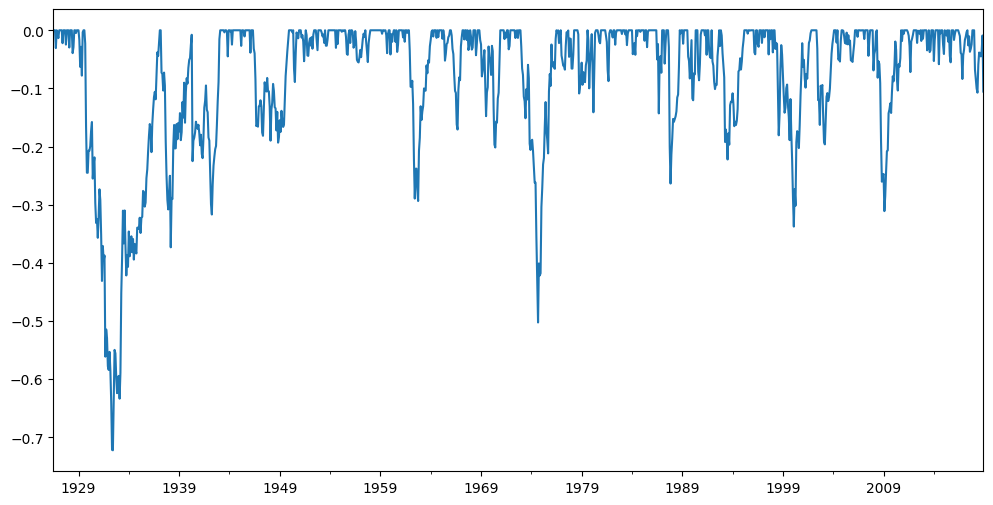

In [4]:
food_drawdown = tk.drawdown(ind['Food'])['Drawdown'].plot(figsize=(12,6 ))

In [5]:
cols_of_interest = ['Food', 'Smoke', 'Coal', 'Beer', 'Fin']
tk.var_gaussian(ind[cols_of_interest], modified=True)

,0
Food,0.061207
Smoke,0.080292
Coal,0.047359
Beer,0.033881
Fin,0.075199


In [6]:
tk.var_gaussian(ind, level=5, modified=True).sort_values().tail()

,0
Carry,0.094527
Meals,0.098403
BusEq,0.099377
Games,0.100701
Mines,0.102782


<Axes: >

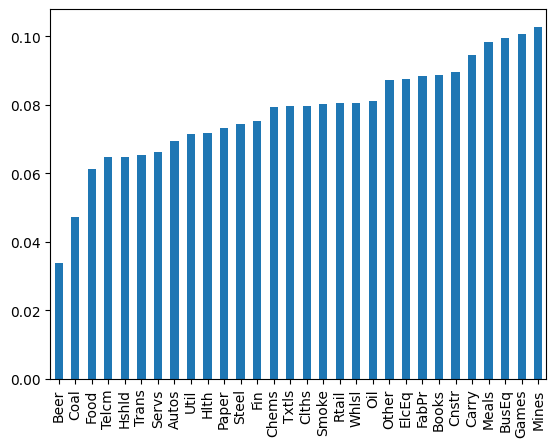

In [7]:
ax = tk.var_gaussian(ind, level=5, modified=True).sort_values()
ax.plot.bar()

In [8]:
annualised_ret = tk.ann_rets(ind['Food'], periods_per_year=12)
annualised_vol = tk.ann_vol(ind['Food'], periods_per_year=12)
ann_sharpe = tk.sharpe_ratio(ind['Food'], periods_per_year=12, riskfree_rate=0.03)

print(f'''Food industry stats
        Annualised return: {round(annualised_ret*100,2)}%
        Annualised volatility: {round(annualised_vol*100,2)}%
        Sharpe ratio: {round(ann_sharpe,2)}''')

Food industry stats
        Annualised return: 10.66%
        Annualised volatility: 16.4%
        Sharpe ratio: 0.45


<Axes: title={'center': 'Industry Sharpe ratios 2000-2018'}>

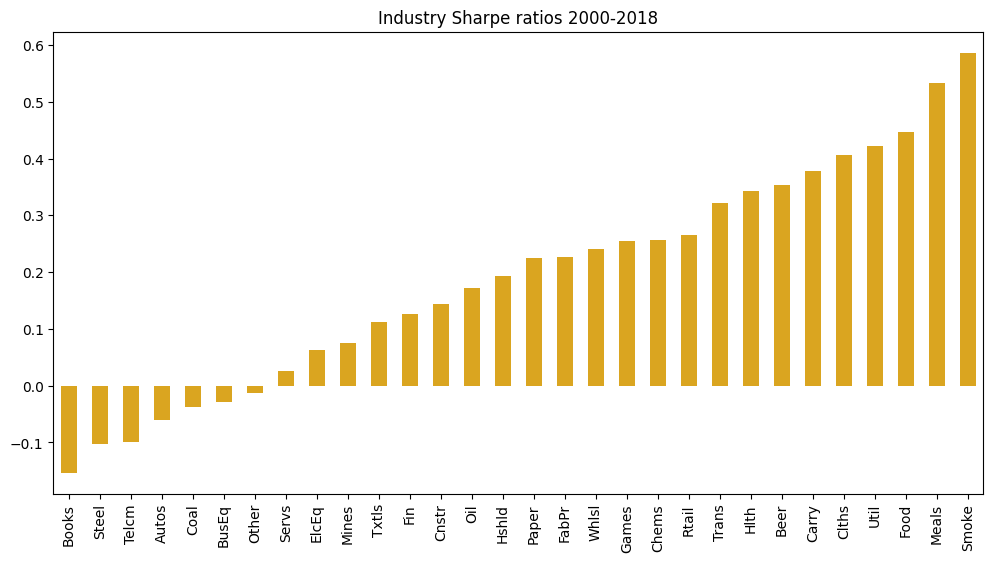

In [9]:
s_chart = tk.sharpe_ratio(ind['2000':], riskfree_rate=0.03, periods_per_year=12).sort_values()
s_chart.plot.bar(title="Industry Sharpe ratios 2000-2018", color='goldenrod', figsize=(12,6))

<Axes: title={'center': 'Industry expected returns 1995-2000'}>

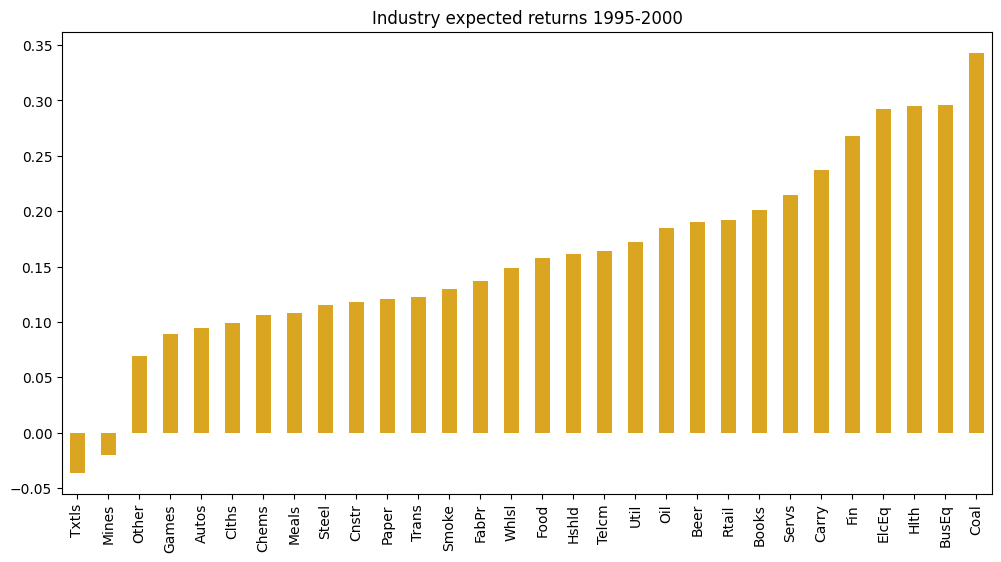

In [10]:
# expected returns subbed for real returns between 95' - 2000

er = tk.ann_rets(ind['1995':'2000'], 12)
er.sort_values().plot.bar(title="Industry expected returns 1995-2000", color='goldenrod', figsize=(12,6))

In [11]:
# Need covariance matrix for MVO
COV =  ind['1995':'2000'].cov()
COV

,Food,Beer,Smoke,Games,Books,Hshld,Clths,Hlth,Chems,Txtls,...,Telcm,Servs,BusEq,Paper,Trans,Whlsl,Rtail,Meals,Fin,Other
Food,0.002287,0.002077,0.001757,0.000701,0.000886,0.001208,0.001474,0.001105,0.001253,0.001021,...,0.000610,0.000211,-0.000280,0.001205,0.001312,0.000633,0.001165,0.001085,0.001839,0.000898
Beer,0.002077,0.004599,0.001143,0.001147,0.000765,0.002447,0.001415,0.001689,0.001292,0.001721,...,0.000978,0.000400,0.000028,0.001455,0.001974,0.000609,0.001442,0.001634,0.002236,0.001196
Smoke,0.001757,0.001143,0.007130,0.000296,-0.000099,0.000981,0.000761,0.000877,0.000687,0.000555,...,0.000057,-0.000266,-0.000300,0.001061,0.000241,0.001363,0.000069,0.000590,0.001117,0.001418
Games,0.000701,0.001147,0.000296,0.003271,0.001485,0.001018,0.001814,0.001219,0.001547,0.001291,...,0.001615,0.002399,0.002935,0.001615,0.001438,0.001681,0.001649,0.001383,0.002080,0.002088
Books,0.000886,0.000765,-0.000099,0.001485,0.002302,0.000876,0.002037,0.000657,0.001559,0.001362,...,0.001627,0.001996,0.001624,0.001481,0.001576,0.001205,0.001995,0.001026,0.001979,0.001283
Hshld,0.001208,0.002447,0.000981,0.001018,0.000876,0.002849,0.001046,0.001253,0.001226,0.001172,...,0.000889,0.001111,0.000906,0.001594,0.001366,0.000578,0.001157,0.001076,0.001652,0.001322
Clths,0.001474,0.001415,0.000761,0.001814,0.002037,0.001046,0.004896,0.000759,0.002547,0.002105,...,0.001263,0.001401,0.000746,0.002683,0.002466,0.001654,0.002607,0.002229,0.002699,0.001974
Hlth,0.001105,0.001689,0.000877,0.001219,0.000657,0.001253,0.000759,0.002252,0.000444,0.000538,...,0.001093,0.001390,0.001264,0.000552,0.000880,0.000907,0.000770,0.000900,0.001412,0.001099
Chems,0.001253,0.001292,0.000687,0.001547,0.001559,0.001226,0.002547,0.000444,0.002944,0.001705,...,0.000860,0.001072,0.000935,0.002581,0.001966,0.001257,0.001661,0.001425,0.002143,0.001832
Txtls,0.001021,0.001721,0.000555,0.001291,0.001362,0.001172,0.002105,0.000538,0.001705,0.002882,...,0.000790,0.000582,0.000685,0.001869,0.001760,0.001426,0.001696,0.001126,0.001789,0.001668


Efficient Frontier Part II

In [12]:
ind = tk.get_ind_returns()
er = tk.ann_rets(ind['1996':'2000'], 12)
cov = ind['1996':'2000'].cov()

def portfolio_return(weights, returns):
    '''
    weights -> returns
    '''
    return weights.T @ returns

def portfolio_vol(weights, covmat):
    '''
    weights -> volatility
    '''
    return (weights.T @ covmat @ weights)**0.5

l = ['Food', 'Beer', 'Smoke', 'Coal']
er[l]

covariance_matrix = cov.loc[l,l]

weights = np.repeat(1/4,4)
print(weights)

port_rets = portfolio_return(weights, er[l])
port_vol = portfolio_vol(weights, covariance_matrix)

print(f'Portfolio expected return: {port_rets.round(4)}')
print(f'Portfolio volatility: {port_vol.round(4)}')
print(f'Portfolio Sharpe: {((port_rets - 0.03) / port_vol).round(2)}')


[0.25 0.25 0.25 0.25]
Portfolio expected return: 0.1951
Portfolio volatility: 0.0551
Portfolio Sharpe: 3.0


# Asset Frontier

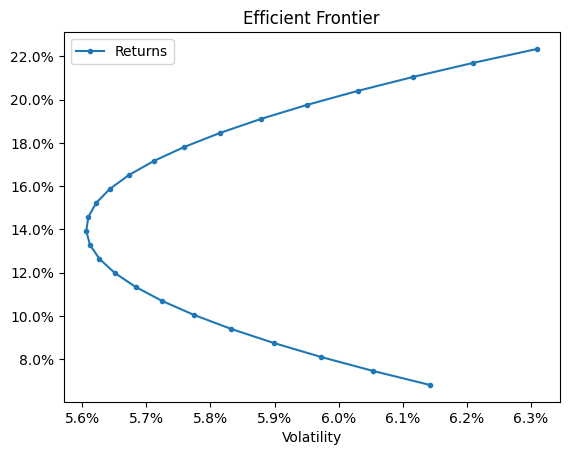

In [13]:
from numpy._core.defchararray import title
l = ["Games", "Fin"]
n_points = 20
weights = [np.array([w, 1-w]) for w in np.linspace(0, 1, n_points)]
rets = [portfolio_return(w, er[l]) for w in weights]
vol = [portfolio_vol(w, cov.loc[l,l]) for w in weights]

ef = pd.DataFrame({"Return": rets,
                   "Volatility": vol})
# ef.plot.line(x="Volatility", y="Return")

def plot_ef2(n_points, er, cov):
  '''
  Plots the 2-asset efficient frontier
  '''
  if er.shape[0] != 2:
    raise ValueError("plot_ef2 can only plot 2-asset frontiers")
  weights = [np.array([w, 1-w]) for w in np.linspace(0, 1, n_points)]
  rets = [portfolio_return(w, er) for w in weights]
  vols = [portfolio_vol(w, cov) for w in weights]
  ef = pd.DataFrame({"Returns": rets,
                    "Volatility": vols})
  ax = ef.plot.line(x="Volatility", y="Returns", style=".-", title="Efficient Frontier")
  ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0, decimals=1))
  return ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0, decimals=1))


plot_ef2(25, er[l], cov.loc[l,l])


# N-Assets Efficient Frontier

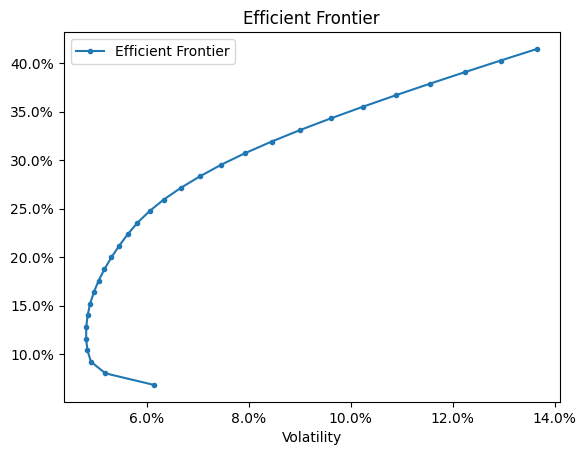

In [14]:
ind = tk.get_ind_returns()
er = tk.ann_rets(ind['1996':'2000'], 12)
cov = ind['1996':'2000'].cov()

l = ['Games', 'Fin', 'Beer', 'Coal', 'Smoke']

tk.plot_ef(30, er[l], cov.loc[l,l])


In [15]:
a = tk.minimise_vol(0.15, er[l], cov.loc[l,l])
b = tk.portfolio_vol(a, cov.loc[l,l])
print(a, b)

[0.32789534 0.18397041 0.19243318 0.08960857 0.2060925 ] 0.048809208167990135


# Cash 'n' Gold play

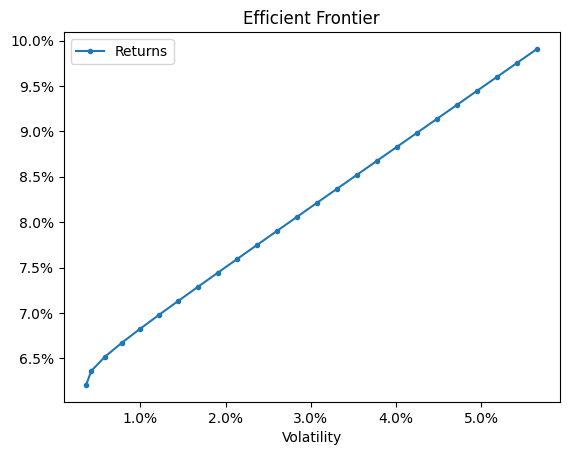

In [16]:
def get_cashngold():
  gdrive_base_path = '/content/drive/MyDrive/'
  # Construct the full path to the data file
  file_path = os.path.join(gdrive_base_path, 'ColabNotebooks', 'EDHEC_Learning', 'data', 'cash_gold_returns.csv')
  data = pd.read_csv(file_path, header=0, index_col=0, parse_dates=True, date_format='%d/%m/%Y')
  data.index = pd.to_datetime(data.index).to_period('M')
  return data

data = get_cashngold()

l = ['Gold M', 'Cash M']
er = tk.ann_rets(data, 12)
cov = data.cov()
plot_ef2(25, er[l], cov.loc[l,l])




# Finding the max Sharpe Ratio portfolio

(0.0, 0.14095245054144764)

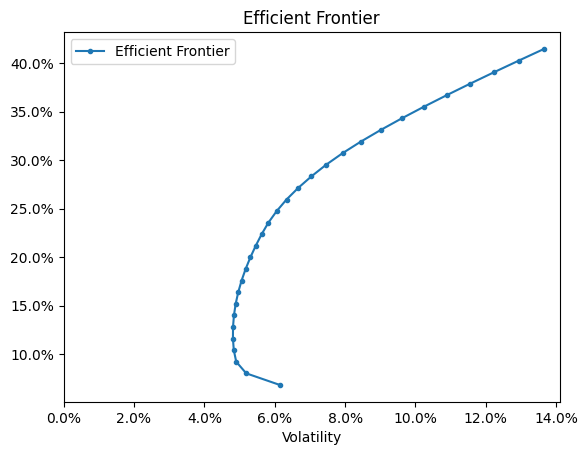

In [17]:
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker



ind = tk.get_ind_returns()
er = tk.ann_rets(ind['1996':'2000'], 12)
cov = ind['1996':'2000'].cov()

l = ['Games', 'Fin', 'Beer', 'Coal', 'Smoke']

# Ensure a figure is created for plotting and then plot the efficient frontier
# plt.figure(figsize=(10,6))
ax = tk.plot_ef(30, er[l], cov.loc[l,l])
ax = plt.gca()
ax.set_xlim(left=0)
# Get the current axes object after tk.plot_ef has drawn


# Adding the CML

<Axes: title={'center': 'Efficient Frontier'}, xlabel='Volatility'>

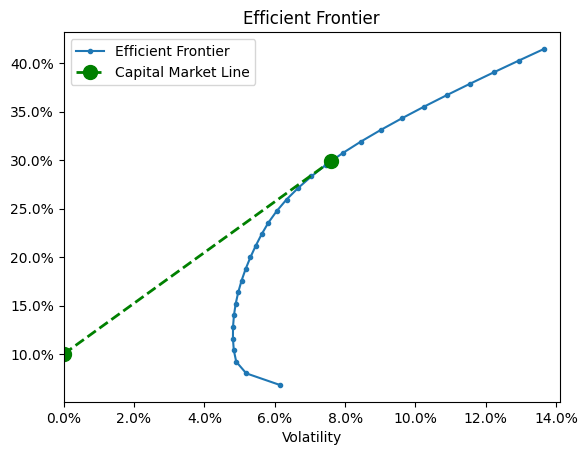

In [18]:
tk.plot_ef(30, er[l], cov.loc[l,l], show_cml=True, riskfree_rate=0.1)


# Lack of robustness in MVO and hte GMV

In [19]:
l = ['Food', 'Steel']
tk.msr(0.1, er[l], cov.loc[l,l])

array([0.75040363, 0.24959637])

In [20]:
er[l]

,0
Food,0.116799
Steel,0.115809


In [21]:
tk.ann_vol(ind[l], 12)

,0
Food,0.163974
Steel,0.292022


In [22]:
cov.loc[l, l]

,Food,Steel
Food,0.002609,0.00007
Steel,0.000070,0.00723


In [23]:
tk.sharpe_ratio(ind[l],0.1,12)

,0
Food,0.036491
Steel,-0.101721


### Optimiser extremely sensitive to inputs
 - error maximising nature of Markowitz

In [24]:
tk.msr(0.1, np.array([0.11, 0.13]), cov.loc[l,l])

array([0.47570951, 0.52429049])

In [25]:
tk.msr(0.1, np.array([0.10, 0.13]), cov.loc[l,l])

array([0., 1.])

In [26]:
tk.msr(0.1, np.array([0.13, 0.10]), cov.loc[l,l])

array([1.0000000e+00, 6.9388939e-18])

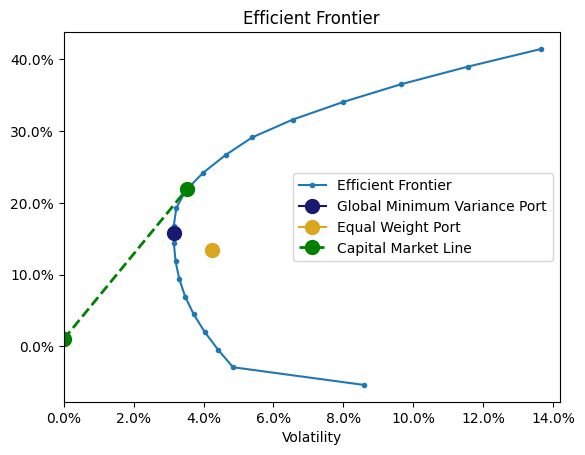

In [28]:
ax = tk.plot_ef(20, er, cov, show_cml=True, riskfree_rate=0.01, show_ew=True, show_gmv=True)